<a href="https://colab.research.google.com/github/cantika-alff/2025_PBO_TI1B/blob/main/UTS_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pandas

matlobitip

Rata-rata Harga per Wilayah:

neighbourhood_group
Bronx             87.50
Queens            99.52
Staten Island    114.81
Brooklyn         124.38
Manhattan        196.88
Name: price, dtype: float64

Jumlah Listing per Jenis Kamar:

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


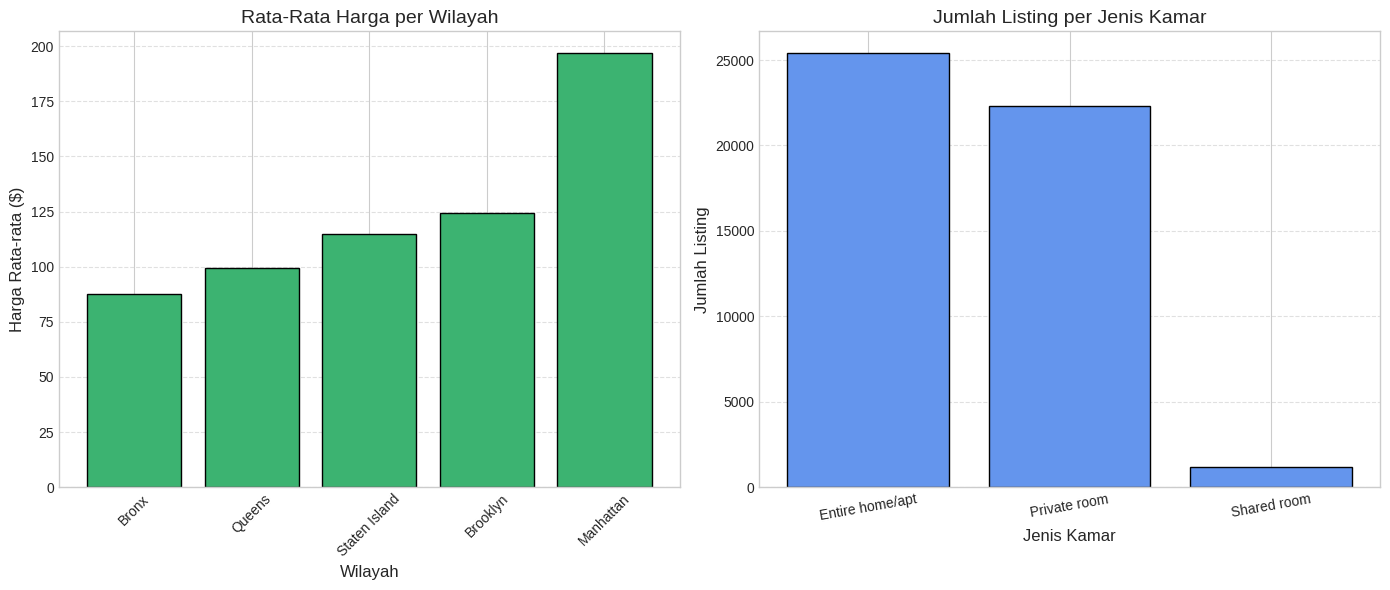

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca data CSV Airbnb
df = pd.read_csv("airbnb.csv")

# Hitung rata-rata harga per wilayah
avg_price_per_area = df.groupby('neighbourhood_group')['price'].mean().sort_values()

# Hitung jumlah listing per jenis kamar
room_type_counts = df['room_type'].value_counts()

# ======== CETAK OUTPUT DATA =========
print("Rata-rata Harga per Wilayah:\n")
print(avg_price_per_area.round(2))
print("\nJumlah Listing per Jenis Kamar:\n")
print(room_type_counts)

# ======== VISUALISASI SUBPLOT =========
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafik 1: Bar chart rata-rata harga per wilayah
axes[0].bar(avg_price_per_area.index, avg_price_per_area.values,
            color='mediumseagreen', edgecolor='black')
axes[0].set_title('Rata-Rata Harga per Wilayah', fontsize=14)
axes[0].set_xlabel('Wilayah', fontsize=12)
axes[0].set_ylabel('Harga Rata-rata ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Grafik 2: Bar chart jumlah listing per room_type
axes[1].bar(room_type_counts.index, room_type_counts.values,
            color='cornflowerblue', edgecolor='black')
axes[1].set_title('Jumlah Listing per Jenis Kamar', fontsize=14)
axes[1].set_xlabel('Jenis Kamar', fontsize=12)
axes[1].set_ylabel('Jumlah Listing', fontsize=12)
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


diagram

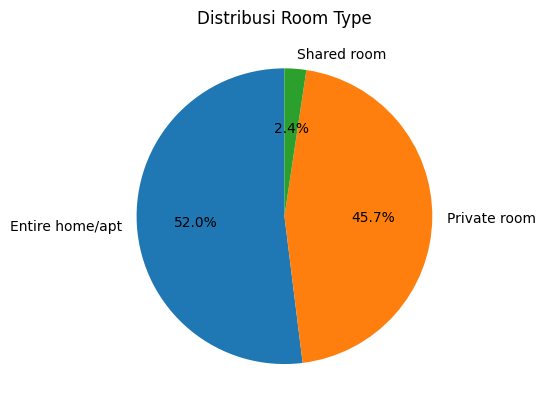

In [ ]:
room_counts = df['room_type'].value_counts()
room_counts.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Distribusi Room Type')
plt.ylabel('')
plt.show()

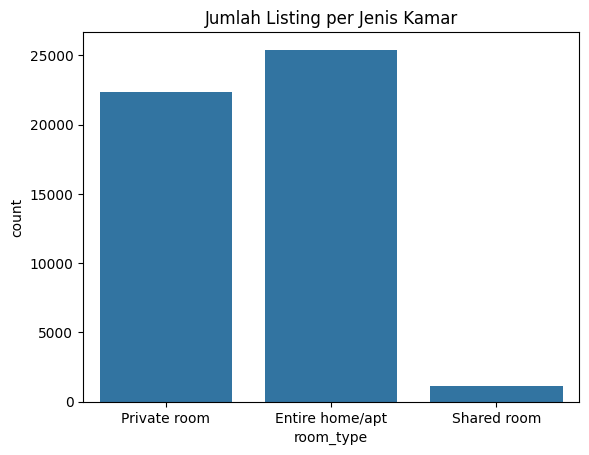

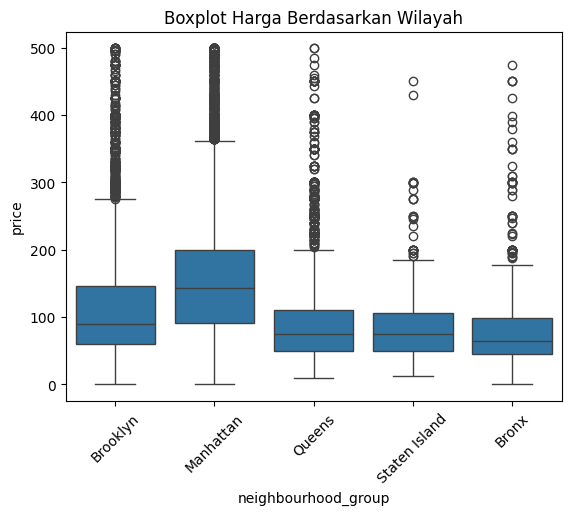

In [ ]:
import seaborn as sns

# Countplot
sns.countplot(data=df, x='room_type')
plt.title("Jumlah Listing per Jenis Kamar")
plt.show()

# Boxplot harga berdasarkan wilayah
sns.boxplot(data=df[df['price'] < 500], x='neighbourhood_group', y='price')
plt.title("Boxplot Harga Berdasarkan Wilayah")
plt.xticks(rotation=45)
plt.show()

INI FIKS

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("airbnb.csv")
# Menampilkan DataFrame
print(df.head())



     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

In [54]:
# Info dan ringkasan data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [55]:
print("\nStatistik deskriptif:")
print(df.describe())


Statistik deskriptif:
                 id       host_id      latitude     longitude         price  \
count  4.889500e+04  4.889500e+04  48895.000000  48895.000000  48895.000000   
mean   1.901714e+07  6.762001e+07     40.728949    -73.952170    152.720687   
std    1.098311e+07  7.861097e+07      0.054530      0.046157    240.154170   
min    2.539000e+03  2.438000e+03     40.499790    -74.244420      0.000000   
25%    9.471945e+06  7.822033e+06     40.690100    -73.983070     69.000000   
50%    1.967728e+07  3.079382e+07     40.723070    -73.955680    106.000000   
75%    2.915218e+07  1.074344e+08     40.763115    -73.936275    175.000000   
max    3.648724e+07  2.743213e+08     40.913060    -73.712990  10000.000000   

       minimum_nights  number_of_reviews  reviews_per_month  \
count    48895.000000       48895.000000       38843.000000   
mean         7.029962          23.274466           1.373221   
std         20.510550          44.550582           1.680442   
min          

In [64]:
#Tipe data setiap kolom
print("\nTipe Data:")
print(df.dtypes)


Tipe Data:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [65]:
# Missing value per kolom
print("\nMissing Value per Kolom:")
print(df.isnull().sum())



Missing Value per Kolom:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [66]:
# Jumlah total data (baris dan kolom)
print("\nJumlah Data:")
print(f"Baris: {df.shape[0]}, Kolom: {df.shape[1]}")


Jumlah Data:
Baris: 48895, Kolom: 16


In [67]:
# Mean, Median, dan Standard Deviasi dari kolom numerik
print("\nStatistik Umum (Mean, Median, Std Dev):")
numeric_cols = df.select_dtypes(include=[np.number])
for col in numeric_cols.columns:
    print(f"\nKolom: {col}")
    print(f"  Mean: {df[col].mean()}")
    print(f"  Median: {df[col].median()}")
    print(f"  Std Dev: {df[col].std()}")


Statistik Umum (Mean, Median, Std Dev):

Kolom: id
  Mean: 19017143.236179568
  Median: 19677284.0
  Std Dev: 10983108.38561011

Kolom: host_id
  Mean: 67620010.64661008
  Median: 30793816.0
  Std Dev: 78610967.03266686

Kolom: latitude
  Mean: 40.72894888066264
  Median: 40.72307
  Std Dev: 0.054530078057371895

Kolom: longitude
  Mean: -73.95216961468454
  Median: -73.95568
  Std Dev: 0.04615673610637182

Kolom: price
  Mean: 152.7206871868289
  Median: 106.0
  Std Dev: 240.15416974718727

Kolom: minimum_nights
  Mean: 7.029962163820431
  Median: 3.0
  Std Dev: 20.510549533180445

Kolom: number_of_reviews
  Mean: 23.274465691788528
  Median: 5.0
  Std Dev: 44.55058226668788

Kolom: reviews_per_month
  Mean: 1.3732214298586618
  Median: 0.72
  Std Dev: 1.6804419952744627

Kolom: calculated_host_listings_count
  Mean: 7.143982002249719
  Median: 1.0
  Std Dev: 32.952518849421466

Kolom: availability_365
  Mean: 112.78132733408324
  Median: 45.0
  Std Dev: 131.62228885170362


In [60]:
# Harga minimum dan maksimum
print("\nHarga Minimum dan Maksimum:")
min_price = df['price'].min()
max_price = df['price'].max()
print(f"  Harga minimum: {min_price}")
print(f"  Harga maksimum: {max_price}")


Harga Minimum dan Maksimum:
  Harga minimum: 0
  Harga maksimum: 10000


In [68]:
# Perbandingan harga minimum dan maksimum
if min_price > 0:
    ratio = max_price / min_price
    print(f"  Perbandingan (maks / min): {ratio:.2f}x")
else:
    print("  Tidak dapat menghitung rasio karena harga minimum adalah 0.")


  Tidak dapat menghitung rasio karena harga minimum adalah 0.


In [69]:
# Perbandingan harga dengan kolom lain
print("\nPerbandingan Harga dengan 'minimum_nights':")
corr = df['price'].corr(df['minimum_nights'])
print(f"  Korelasi antara harga dan minimum_nights: {corr:.2f}")


Perbandingan Harga dengan 'minimum_nights':
  Korelasi antara harga dan minimum_nights: 0.04


In [36]:
# Series: Mengakses satu kolom
print("\nContoh Series kolom 'price':")
print(df['price'].head())



Contoh Series kolom 'price':
0    149
1    225
2    150
3     89
4     80
Name: price, dtype: int64


In [37]:
# Manipulasi DataFrame
df['price_per_night'] = df['price'] / df['minimum_nights']
df['price_per_night'] = df['price_per_night'].replace([float('inf'), float('nan')], 0)
print("\nKolom baru 'price_per_night' ditambahkan:")



Kolom baru 'price_per_night' ditambahkan:


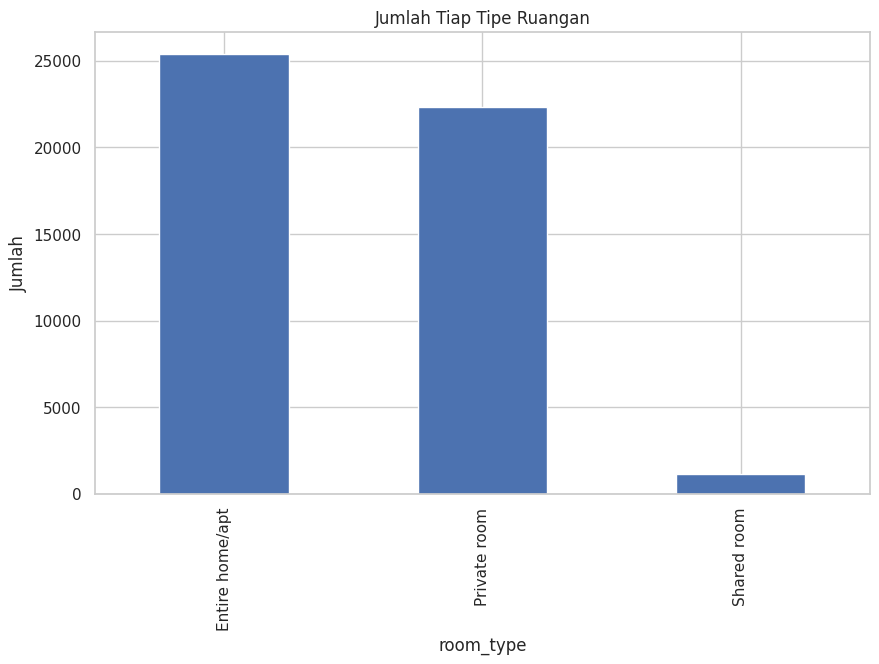

In [70]:
# Plotting
df['room_type'].value_counts().plot(kind='bar', title='Jumlah Tiap Tipe Ruangan')
plt.ylabel("Jumlah")
plt.show()

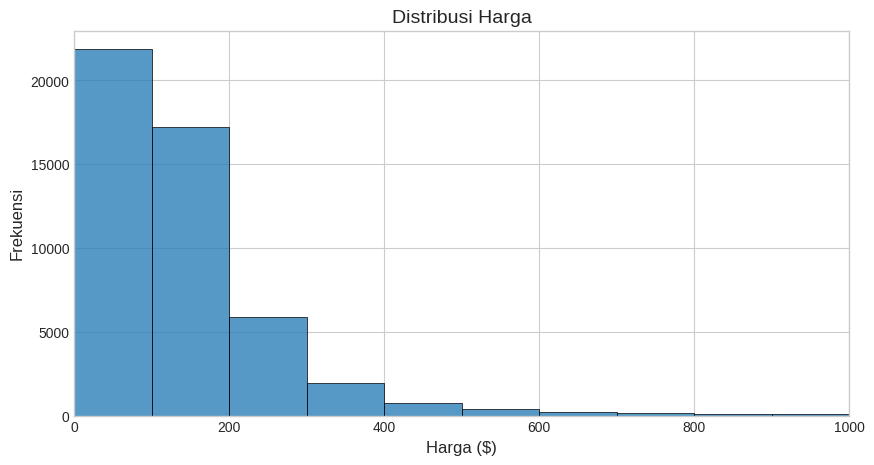

In [39]:
# Histogram Harga
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=100, kde=False)
plt.title("Distribusi Harga", fontsize=14)
plt.xlabel("Harga ($)", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.xlim(0, 1000)
plt.grid(True)
plt.show()

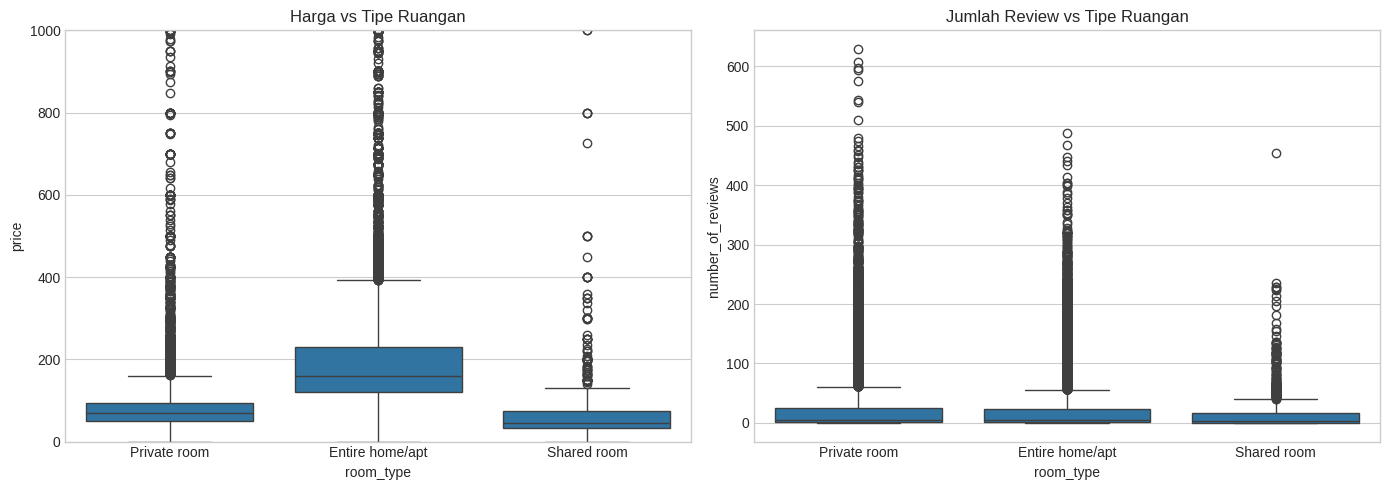

In [42]:
# Subplot perbandingan harga dan jumlah review
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Harga
sns.boxplot(x='room_type', y='price', data=df, ax=axs[0])
axs[0].set_title("Harga vs Tipe Ruangan")
axs[0].set_ylim(0, 1000)

# Jumlah review
sns.boxplot(x='room_type', y='number_of_reviews', data=df, ax=axs[1])
axs[1].set_title("Jumlah Review vs Tipe Ruangan")

plt.tight_layout()
plt.show()

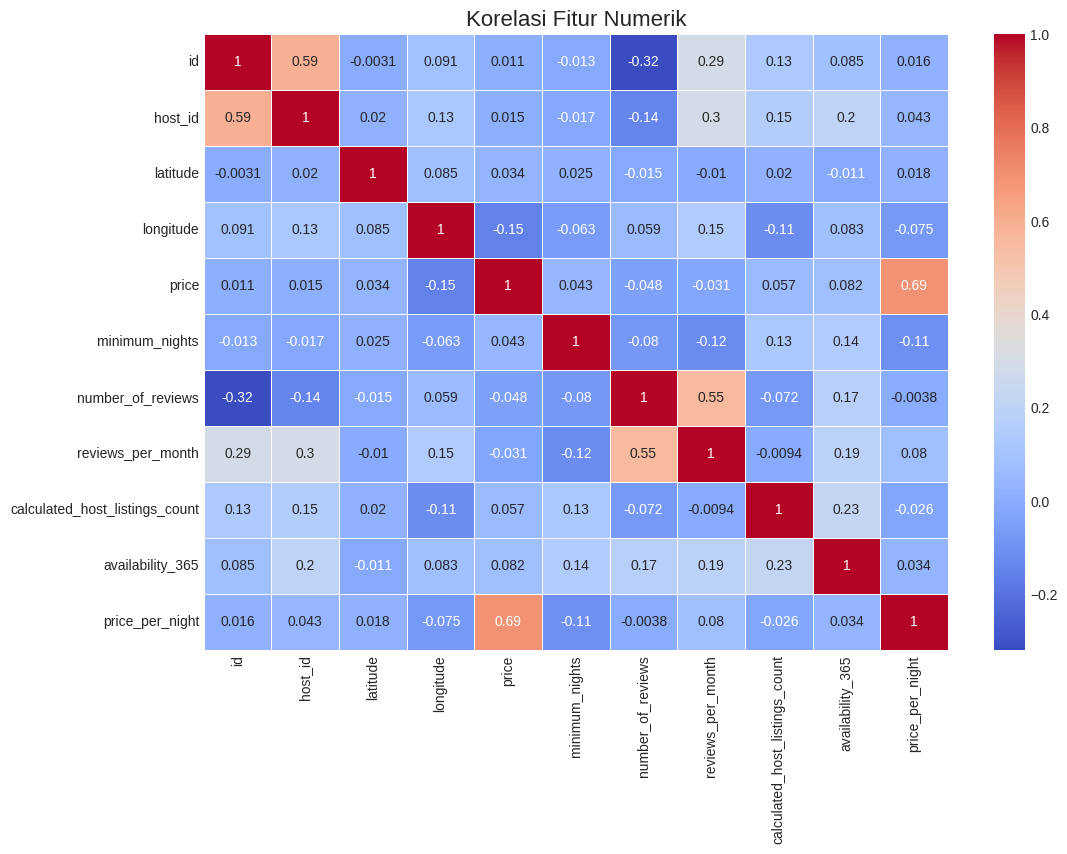

In [43]:
# Heatmap korelasi
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Korelasi Fitur Numerik", fontsize=16)
plt.show()

In [47]:
# Grouping dan Aggregasi
avg_price_neigh = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
print("\nRata-rata Harga per Neighbourhood Group:")
print(avg_price_neigh)



Rata-rata Harga per Neighbourhood Group:
neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64


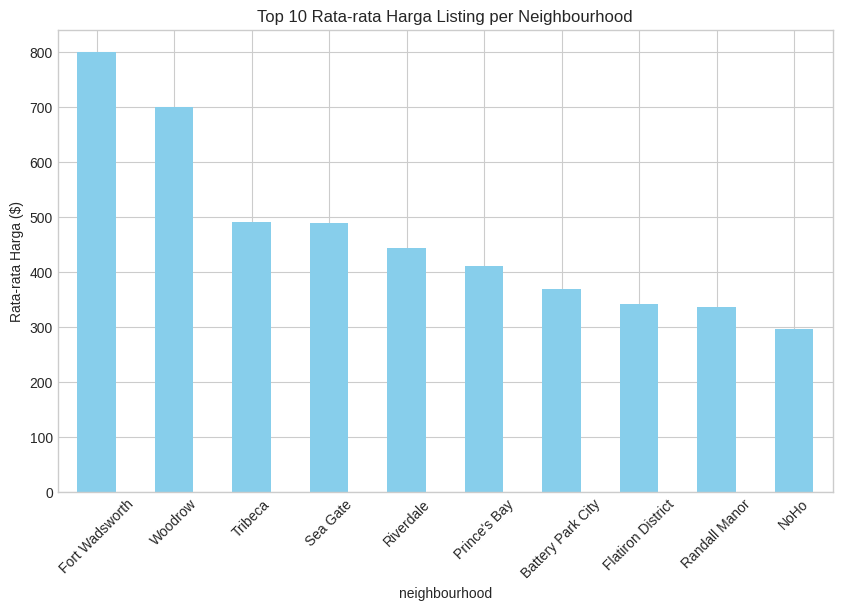

In [48]:
# Top 10 Neighbourhoods dengan harga rata-rata tertinggi
top10_neigh = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top10_neigh.plot(kind='bar', color='skyblue')
plt.title("Top 10 Rata-rata Harga Listing per Neighbourhood")
plt.ylabel("Rata-rata Harga ($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

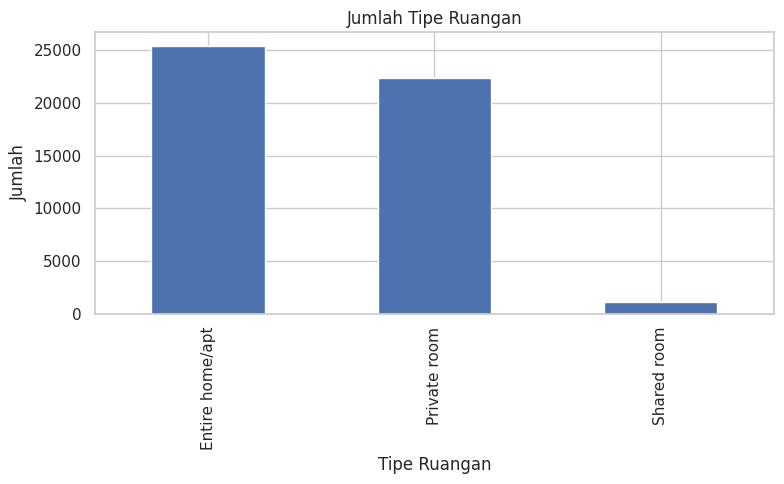

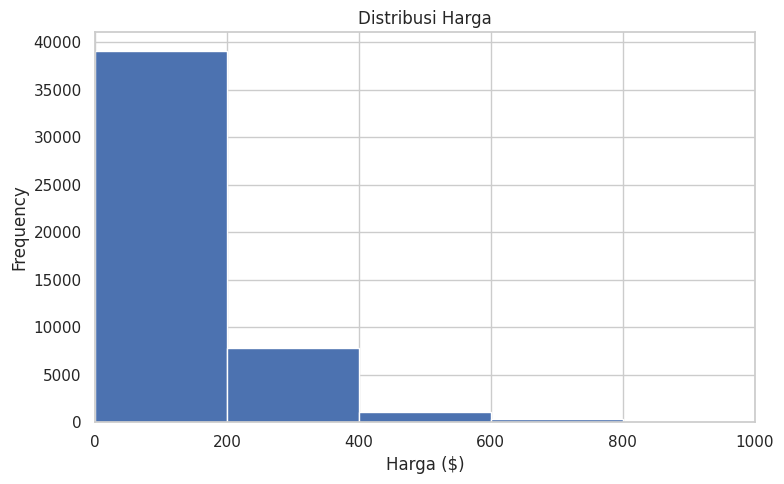

In [72]:
import matplotlib.pyplot as plt

# Plot 1: Jumlah tipe ruangan
plt.figure(figsize=(8,5))
df['room_type'].value_counts().plot(kind='bar', title='Jumlah Tipe Ruangan')
plt.xlabel("Tipe Ruangan")
plt.ylabel("Jumlah")
plt.tight_layout()  # memberi ruang agar tidak bertabrakan
plt.show()

# Plot 2: Distribusi harga
plt.figure(figsize=(8,5))
df['price'].plot(kind='hist', bins=50, title='Distribusi Harga', xlim=(0, 1000))
plt.xlabel("Harga ($)")
plt.ylabel("Frequency")
plt.tight_layout()  # memberi jarak agar lebih rapi
plt.show()


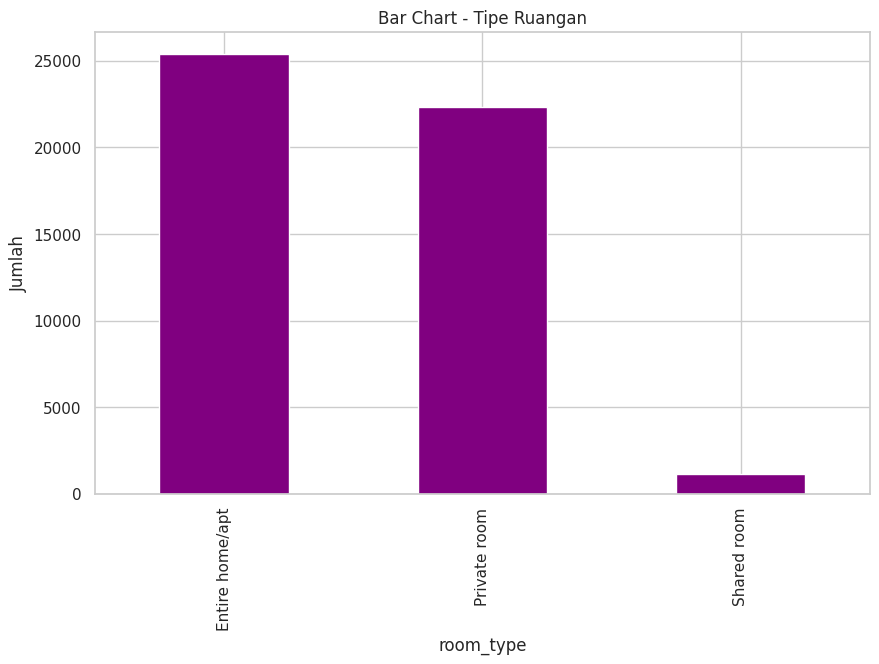

In [81]:
# Bar chart: Tipe ruangan
df['room_type'].value_counts().plot(kind='bar', color='purple', title='Bar Chart - Tipe Ruangan')
plt.ylabel("Jumlah")
plt.show()



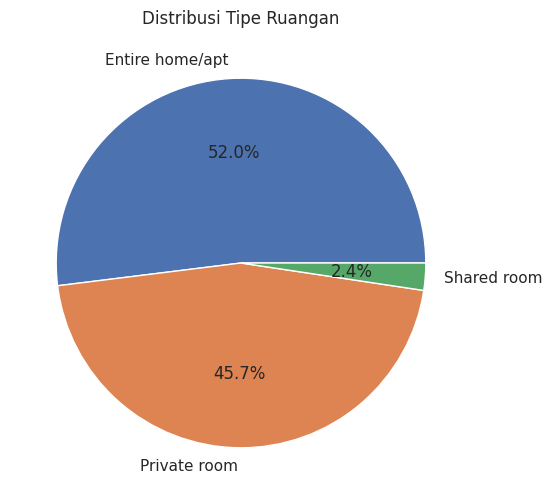

In [82]:
# Pie chart: Distribusi tipe ruangan
df['room_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Distribusi Tipe Ruangan', figsize=(6,6))
plt.ylabel("")
plt.show()

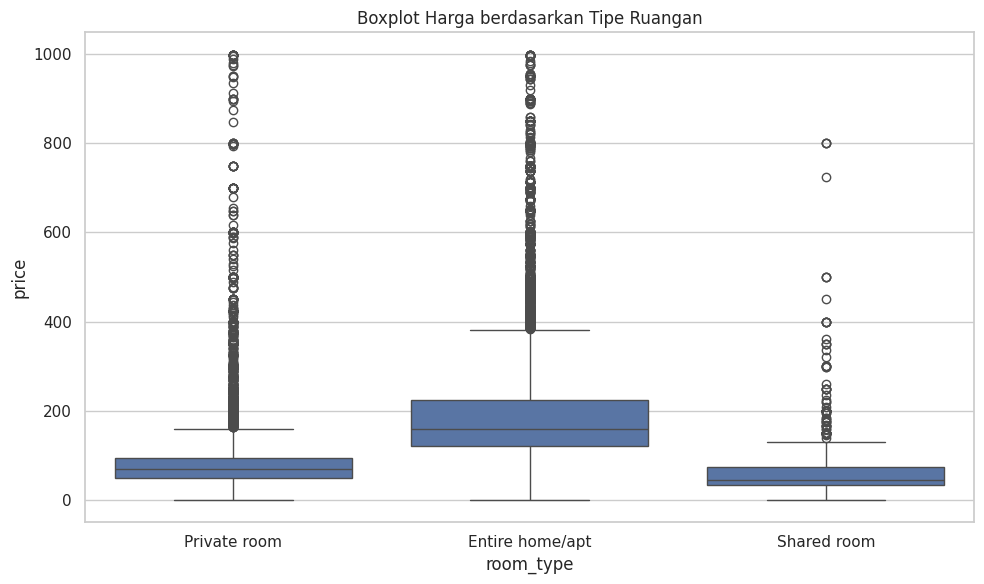

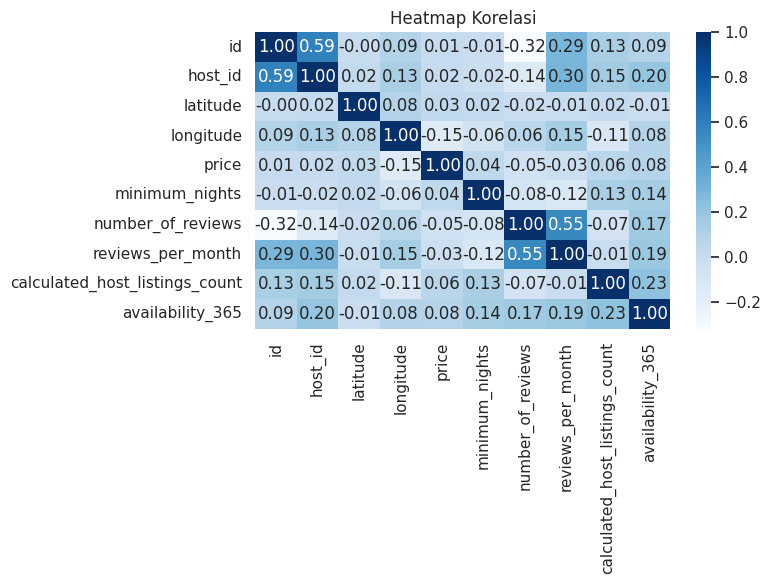

In [79]:
import seaborn as sns

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['price'] < 1000], x='room_type', y='price')
plt.title("Boxplot Harga berdasarkan Tipe Ruangan")
plt.tight_layout()
plt.show()

# Heatmap korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', fmt=".2f")
plt.title("Heatmap Korelasi")
plt.tight_layout()
plt.show()
